In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Konfiguracja wyglądu wykresów

In [22]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 2. Bezpieczne ładowanie danych

In [ ]:
sciezki = ['../data/raw/erp_demand_history.csv', '03_demand_forecasting/data/raw/erp_demand_history.csv', 'erp_demand_history.csv']
df = None

for sciezka in sciezki:
    try:
        # encoding='utf-8-sig' automatycznie usuwa ukryte znaki kodowania Windowsa (\ufeff)
        df = pd.read_csv(sciezka, encoding='utf-8-sig')
        
        # Dodatkowo czyścimy nazwy kolumn z ewentualnych spacji
        df.columns = df.columns.str.strip()
        
        print(f"Pomyślnie załadowano historię popytu z: {sciezka}")
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError("Błąd: Nie znaleziono pliku erp_demand_history.csv!")


Pomyślnie załadowano historię popytu z: erp_demand_history.csv


# 3. ANALIZA I FORECASTING (Prognozowanie na I kwartał 2026)

In [24]:
# Obliczamy odchylenie standardowe, aby wyznaczyć stabilność popytu
demand_std = df['ordered_qty'].std()
# Zapas bezpieczeństwa = 1.65 (dla 95% poziomu obsługi klienta) * odchylenie standardowe
safety_stock = int(1.65 * demand_std)

# Generujemy prognozę na kolejne 3 miesiące (Q1 2026) na bazie średniej ważonej z ostatnich miesięcy
ostatnie_zuzycie = df['ordered_qty'].tail(3).mean()
procentowy_wzrost_yoy = 1.10 # zakładamy 10% wzrostu rynku rok do roku

forecast_months = ['2026-01', '2026-02', '2026-03']
forecast_values = [
    int(ostatnie_zuzycie * 0.65 * procentowy_wzrost_yoy),  # Styczeń (spadek poświąteczny)
    int(ostatnie_zuzycie * 0.72 * procentowy_wzrost_yoy),  # Luty
    int(ostatnie_zuzycie * 0.85 * procentowy_wzrost_yoy)   # Marzec (początek wiosennego sezonu)
]

# Przygotowanie danych do wizualizacji
df_hist = df.copy()
df_forecast = pd.DataFrame({
    'month': forecast_months,
    'product_id': 'SZAFA_PAX_01',
    'ordered_qty': forecast_values
})

print("PROGNOZA POPYTU NA Q1 2026:")
for m, v in zip(forecast_months, forecast_values):
    print(f"Miesiąc: {m} | Prognozowane zapotrzebowanie: {v} szt. | Sugerowany Zapas Bezpieczeństwa: {safety_stock} szt.")

PROGNOZA POPYTU NA Q1 2026:
Miesiąc: 2026-01 | Prognozowane zapotrzebowanie: 170 szt. | Sugerowany Zapas Bezpieczeństwa: 65 szt.
Miesiąc: 2026-02 | Prognozowane zapotrzebowanie: 188 szt. | Sugerowany Zapas Bezpieczeństwa: 65 szt.
Miesiąc: 2026-03 | Prognozowane zapotrzebowanie: 222 szt. | Sugerowany Zapas Bezpieczeństwa: 65 szt.


# 4. WIZUALIZACJA LOGISTYCZNA (Line Plot + Safety Stock Zone)

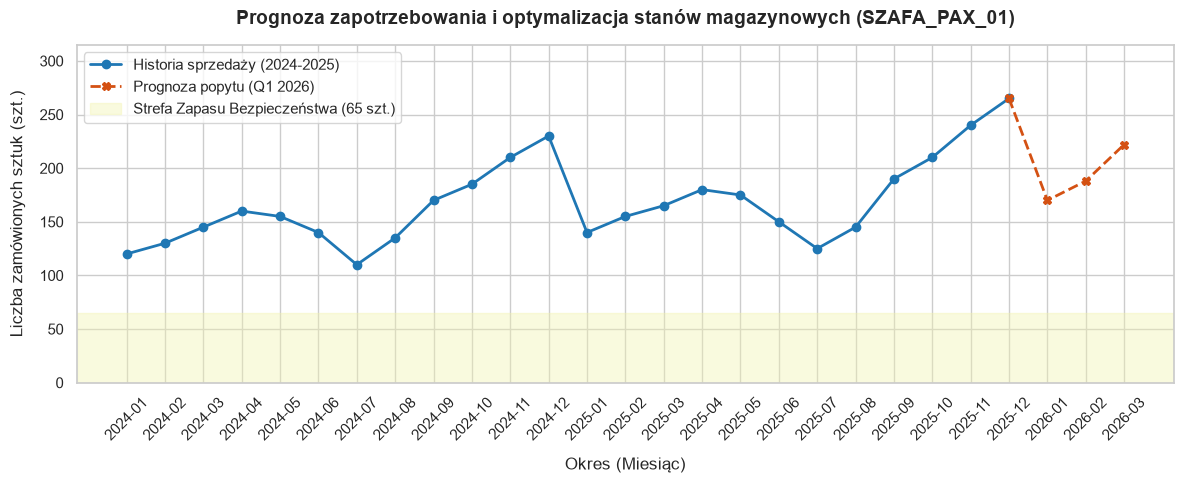

In [25]:
plt.figure(figsize=(12, 5))

# Linia historii
plt.plot(df_hist['month'], df_hist['ordered_qty'], marker='o', color='#1f77b4', linewidth=2, label='Historia sprzedaży (2024-2025)')

# Linia prognozy (połączona z ostatnim punktem historii)
ostatni_punkt_x = [df_hist['month'].iloc[-1]] + forecast_months
ostatni_punkt_y = [df_hist['ordered_qty'].iloc[-1]] + forecast_values
plt.plot(ostatni_punkt_x, p_y := ostatni_punkt_y, marker='X', color='#d45113', linestyle='--', linewidth=2, label='Prognoza popytu (Q1 2026)')

# Zapas bezpieczeństwa jako zacieniony obszar na dole wykresu
plt.axhspan(0, safety_stock, color='#f2f3ae', alpha=0.4, label=f'Strefa Zapasu Bezpieczeństwa ({safety_stock} szt.)')

# Estetyka i opisy biznesowe
plt.title('Prognoza zapotrzebowania i optymalizacja stanów magazynowych (SZAFA_PAX_01)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Okres (Miesiąc)', fontsize=12, labelpad=10)
plt.ylabel('Liczba zamówionych sztuk (szt.)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.ylim(0, max(df_hist['ordered_qty']) + 50)

plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.tight_layout()

# Zapis wykresu do folderu raportów
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/prognoza_popytu_pax_safety_stock.png', dpi=300)
plt.show()